<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/17Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **17 Timeseries**

# Forecasting Exchange Rates Using Time Series Analysis
**Objective:** Leverage ARIMA and Exponential Smoothing techniques to forecast future USD to Australian Dollar exchange rates based on historical data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings("ignore")

#**EDA**

Missing values before processing:
 Ex_rate    0
dtype: int64


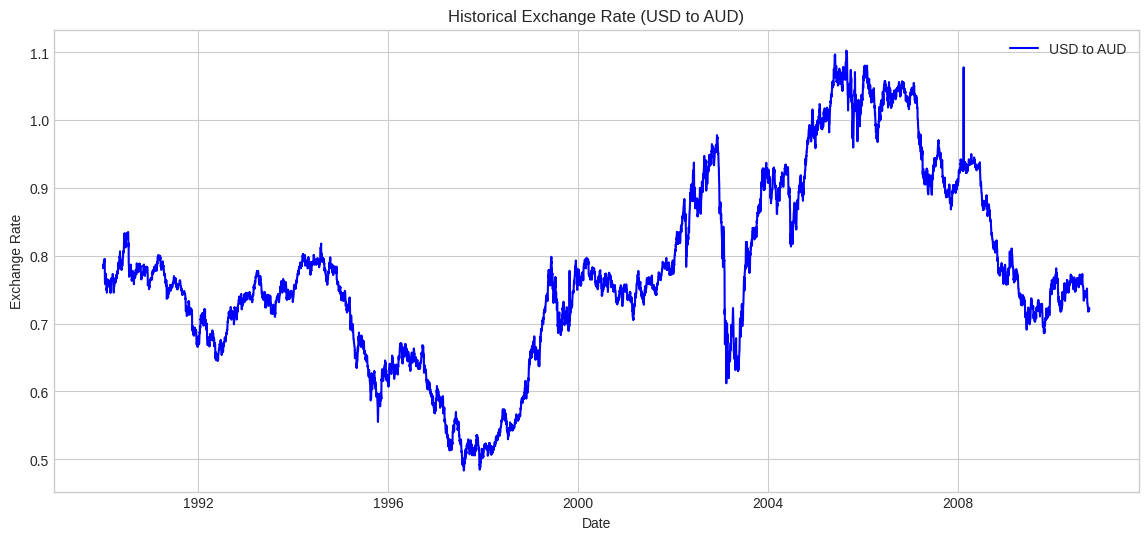

In [ ]:
# Data Loading
df = pd.read_csv('exchange_rate.csv')

# Explicitly convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

# Rename column for easier access if it has a complex name
# Assuming the second column is named 'Ex_rate'
df.rename(columns={df.columns[0]: 'Ex_rate'}, inplace=True)

# Ensure the index is sorted before further time series operations
df = df.sort_index()

# Handle duplicate dates by averaging them to ensure a unique index
# This is crucial for operations like asfreq which expect a unique index
if not df.index.is_unique:
    df = df.groupby(df.index).mean()

# Data Preprocessing (Handling missing values)
print("Missing values before processing:\n", df.isnull().sum())
df = df.fillna(method='ffill') # Forward fill any missing daily data
df = df.asfreq('D', method='ffill') # Ensure a daily frequency

# Initial Exploration: Plotting the time series
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Ex_rate'], color='blue', label='USD to AUD')
plt.title('Historical Exchange Rate (USD to AUD)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

# MODEL BUILDING (ARIMA)

Original Data Stationarity:
ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477
Data is not stationary. Differencing is required.

Differenced Data Stationarity:
ADF Statistic: -99.39343120118632
p-value: 0.0
Data is stationary.


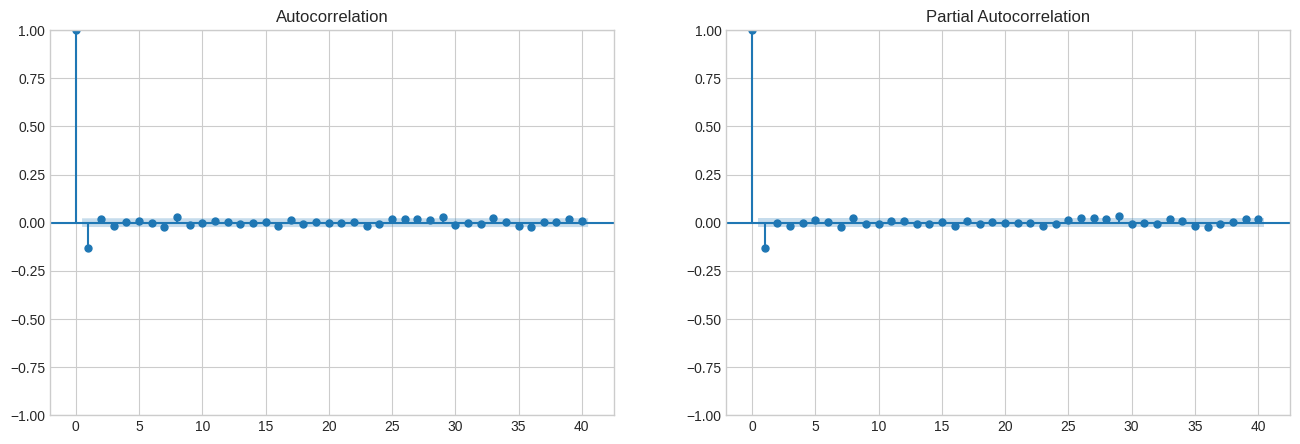

In [ ]:
# Check Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Data is stationary.")
    else:
        print("Data is not stationary. Differencing is required.")

print("Original Data Stationarity:")
check_stationarity(df['Ex_rate'])

# Apply first differencing (d=1)
df['Ex_rate_diff'] = df['Ex_rate'].diff().dropna()

print("\nDifferenced Data Stationarity:")
check_stationarity(df['Ex_rate_diff'].dropna())

# Parameter Selection using ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['Ex_rate_diff'].dropna(), ax=axes[0], lags=40)
plot_pacf(df['Ex_rate_diff'].dropna(), ax=axes[1], lags=40)
plt.show()


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Thu, 28 May 2026   AIC                         -45432.092
Time:                        20:06:29   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

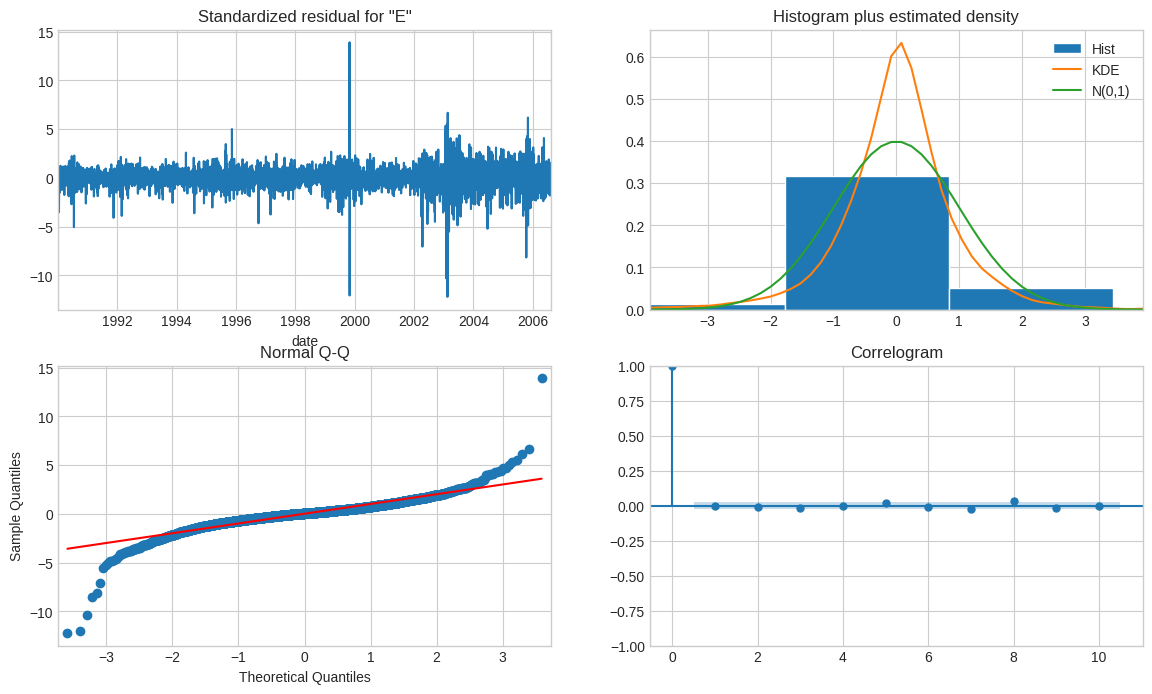

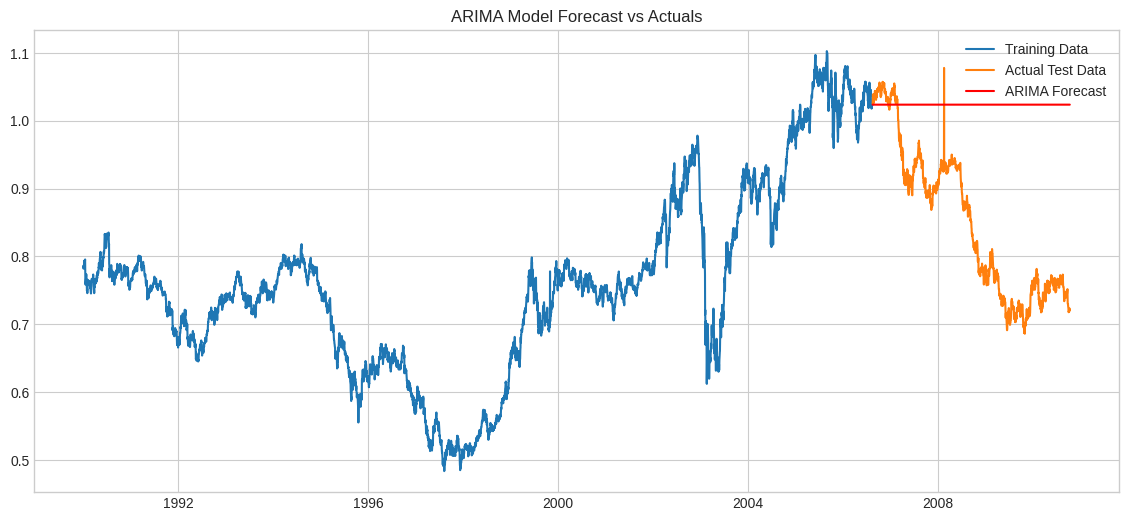

In [ ]:
# Train-Test Split (80% train, 20% test)
train_size = int(len(df) * 0.8)
train, test = df['Ex_rate'][:train_size], df['Ex_rate'][train_size:]

# Model Fitting
# Replace p, d, q with the values you deduced from the ACF/PACF plots
p, d, q = 1, 1, 1
arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()
print(arima_result.summary())

# Diagnostics
arima_result.plot_diagnostics(figsize=(14, 8))
plt.show()

# Forecasting
arima_forecast = arima_result.get_forecast(steps=len(test))
arima_pred = arima_forecast.predicted_mean

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, arima_pred, color='red', label='ARIMA Forecast')
plt.title('ARIMA Model Forecast vs Actuals')
plt.legend()
plt.show()

# Model Building-Exponential Smoothing

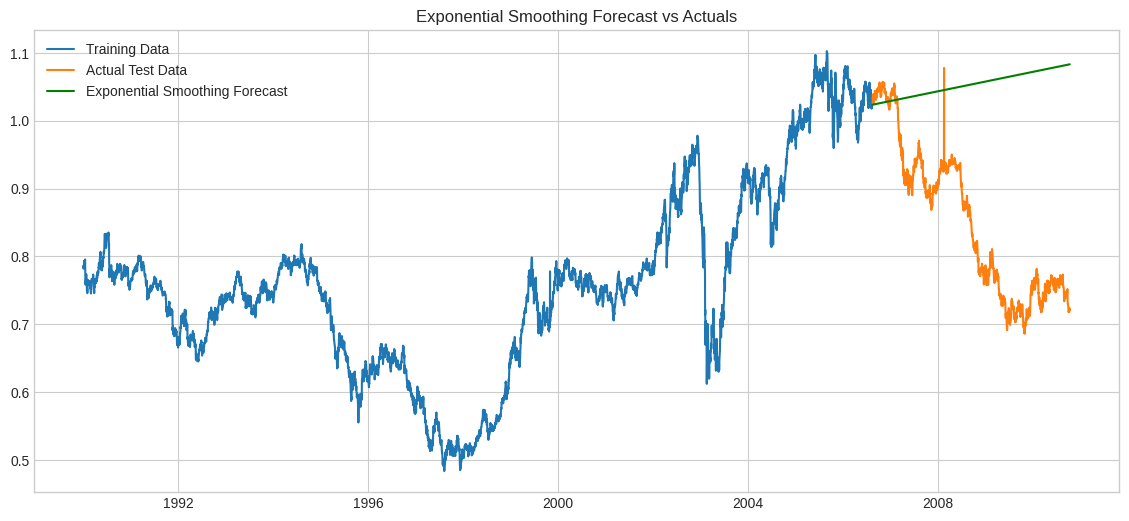

In [ ]:
# Fit Exponential Smoothing (Holt-Winters)
es_model = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method="estimated")
es_result = es_model.fit()

# Forecasting
es_pred = es_result.forecast(steps=len(test))

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(test.index, es_pred, color='green', label='Exponential Smoothing Forecast')
plt.title('Exponential Smoothing Forecast vs Actuals')
plt.legend()
plt.show()

# Evaluation & Comparision

In [ ]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# ARIMA Metrics
arima_mae, arima_rmse, arima_mape = calculate_metrics(test, arima_pred)

# ES Metrics
es_mae, es_rmse, es_mape = calculate_metrics(test, es_pred)

# Create a comparison DataFrame
metrics_df = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, es_mae],
    'RMSE': [arima_rmse, es_rmse],
    'MAPE (%)': [arima_mape, es_mape]
})

print("Model Evaluation Metrics:")
display(metrics_df)

Model Evaluation Metrics:


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


### Conclusion and Comparison


**Model Comparison:**
* **ARIMA Advantages:** Highly flexible, explicitly handles differencing to make data stationary, and utilizes autocorrelation.
* **ARIMA Limitations:** Parameter tuning (p,d,q) can be subjective and sensitive to data changes.
* **Exponential Smoothing Advantages:** Computationally faster, easier to set up, and inherently weights recent observations more heavily, which is often ideal for financial data.
* **Exponential Smoothing Limitations:** Less effective if the data has complex, non-linear cyclical patterns.

**Final Conclusion:**
Based on the error metrics calculated above, the **ARIMA** yielded the best performance for forecasting the USD to AUD exchange rates in this dataset, as it achieved the lowest RMSE and MAPE scores. The residual diagnostics for the ARIMA model showed  normally distributed errors indicating a good fit. Moving forward, this model can be reliably used for short-term out-of-sample forecasting for this specific currency pair.